In [1]:
import collections
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

There are three built-in RNN layers in Keras:

1. tf.keras.layers.SimpleRNN, a fully-connected RNN where the output from previous timestep is to be fed to next timestep.

2. tf.keras.layers.GRU, first proposed in Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation.

3. tf.keras.layers.LSTM, first proposed in Long Short-Term Memory.

In early 2015, Keras had the first reusable open-source Python implementations of LSTM and GRU.

Here is a simple example of a Sequential model that processes sequences of integers, embeds each integer into a 64-dimensional vector, then processes the sequence of vectors using a LSTM layer.

In [2]:
model = tf.keras.Sequential()
# Add an Embedding layer expecting input vocab of size 1000, and
# output embedding dimension of size 64.
model.add(layers.Embedding(input_dim=1000, output_dim=64))

# Add a LSTM layer with 128 internal units.
model.add(layers.LSTM(128))

# Add a Dense layer with 10 units.
model.add(layers.Dense(10))

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, None, 64)          64000     
_________________________________________________________________
lstm (LSTM)                  (None, 128)               98816     
_________________________________________________________________
dense (Dense)                (None, 10)                1290      
Total params: 164,106
Trainable params: 164,106
Non-trainable params: 0
_________________________________________________________________


By default, the output of a RNN layer contain a single vector per sample. This vector is the RNN cell output corresponding to the last timestep, containing information about the entire input sequence. The shape of this output is (batch_size, units) where units corresponds to the units argument passed to the layer's constructor.

A RNN layer can also return the entire sequence of outputs for each sample (one vector per timestep per sample), if you set return_sequences=True. The shape of this output is (batch_size, timesteps, units).

In [3]:
model = tf.keras.Sequential()
model.add(layers.Embedding(input_dim=1000, output_dim=64))

# The output of GRU will be a 3D tensor of shape (batch_size, timesteps, 256)
model.add(layers.GRU(256, return_sequences=True))

# The output of SimpleRNN will be a 2D tensor of shape (batch_size, 128)
model.add(layers.SimpleRNN(128))

model.add(layers.Dense(10))

model.summary() 

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, None, 64)          64000     
_________________________________________________________________
gru (GRU)                    (None, None, 256)         247296    
_________________________________________________________________
simple_rnn (SimpleRNN)       (None, 128)               49280     
_________________________________________________________________
dense_1 (Dense)              (None, 10)                1290      
Total params: 361,866
Trainable params: 361,866
Non-trainable params: 0
_________________________________________________________________


In addition, a RNN layer can return its final internal state(s). The returned states can be used to resume the RNN execution later, or to initialize another RNN. This setting is commonly used in the encoder-decoder sequence-to-sequence model, where the encoder final state is used as the initial state of the decoder.

To configure a RNN layer to return its internal state, set the return_state parameter to True when creating the layer. Note that LSTM has 2 state tensors, but GRU only has one.

To configure the initial state of the layer, just call the layer with additional keyword argument initial_state. Note that the shape of the state needs to match the unit size of the layer, like in the example below.

In [4]:
encoder_vocab = 1000
decoder_vocab = 2000

encoder_input = layers.Input(shape=(None, ))
encoder_embedded = layers.Embedding(input_dim=encoder_vocab, output_dim=64)(encoder_input)

# Return states in addition to output
output, state_h, state_c = layers.LSTM(
    64, return_state=True, name='encoder')(encoder_embedded)
encoder_state = [state_h, state_c]

decoder_input = layers.Input(shape=(None, ))
decoder_embedded = layers.Embedding(input_dim=decoder_vocab, output_dim=64)(decoder_input)

# Pass the 2 states to a new LSTM layer, as initial state
decoder_output = layers.LSTM(
    64, name='decoder')(decoder_embedded, initial_state=encoder_state)
output = layers.Dense(10)(decoder_output)

model = tf.keras.Model([encoder_input, decoder_input], output)
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, None)]       0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, None)]       0                                            
__________________________________________________________________________________________________
embedding_2 (Embedding)         (None, None, 64)     64000       input_1[0][0]                    
__________________________________________________________________________________________________
embedding_3 (Embedding)         (None, None, 64)     128000      input_2[0][0]                    
______________________________________________________________________________________________

#### Bidirectional RNNs
For sequences other than time series (e.g. text), it is often the case that a RNN model can perform better if it not only processes sequence from start to end, but also backwards. For example, to predict the next word in a sentence, it is often useful to have the context around the word, not only just the words that come before it.

Keras provides an easy API for you to build such bidirectional RNNs: the tf.keras.layers.Bidirectional wrapper.

Under the hood, Bidirectional will copy the RNN layer passed in, and flip the go_backwards field of the newly copied layer, so that it will process the inputs in reverse order.

In [5]:
model = tf.keras.Sequential()

model.add(layers.Bidirectional(layers.LSTM(64, return_sequences=True), 
                               input_shape=(5, 10)))
model.add(layers.Bidirectional(layers.LSTM(32)))
model.add(layers.Dense(10))

model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
bidirectional (Bidirectional (None, 5, 128)            38400     
_________________________________________________________________
bidirectional_1 (Bidirection (None, 64)                41216     
_________________________________________________________________
dense_3 (Dense)              (None, 10)                650       
Total params: 80,266
Trainable params: 80,266
Non-trainable params: 0
_________________________________________________________________


### Performance optimization and CuDNN kernels in TensorFlow 2.0

In TensorFlow 2.0, the built-in LSTM and GRU layers have been updated to leverage CuDNN kernels by default when a GPU is available. With this change, the prior keras.layers.CuDNNLSTM/CuDNNGRU layers have been deprecated, and you can build your model without worrying about the hardware it will run on.

Since the CuDNN kernel is built with certain assumptions, this means the layer will not be able to use the CuDNN kernel if you change the defaults of the built-in LSTM or GRU layers. E.g.:

~ Changing the activation function from tanh to something else.

~ Changing the recurrent_activation function from sigmoid to something else.

~ Using recurrent_dropout > 0.

~ Setting unroll to True, which forces LSTM/GRU to decompose the inner tf.while_loop into an unrolled for loop.

~ Setting use_bias to False.

~ Using masking when the input data is not strictly right padded (if the mask corresponds to strictly right padded data, CuDNN can still be used. This is the most common case).

For the detailed list of constraints, please see the documentation for the LSTM and GRU layers.

Using CuDNN kernels when available
Let's build a simple LSTM model to demonstrate the performance difference.

We'll use as input sequences the sequence of rows of MNIST digits (treating each row of pixels as a timestep), and we'll predict the digit's label.

In [6]:
batch_size = 64
# Each MNIST image batch is a tensor of shape (batch_size, 28, 28).
# Each input sequence will be of size (28, 28) (height is treated like time).
input_dim = 28

units = 64
output_size = 10  # labels are from 0 to 9

# Build the RNN model
def build_model(allow_cudnn_kernel=True):
  # CuDNN is only available at the layer level, and not at the cell level.
  # This means `LSTM(units)` will use the CuDNN kernel,
  # while RNN(LSTMCell(units)) will run on non-CuDNN kernel.
  if allow_cudnn_kernel:
    # The LSTM layer with default options uses CuDNN.
    lstm_layer = tf.keras.layers.LSTM(units, input_shape=(None, input_dim))
  else:
    # Wrapping a LSTMCell in a RNN layer will not use CuDNN.
    lstm_layer = tf.keras.layers.RNN(
        tf.keras.layers.LSTMCell(units),
        input_shape=(None, input_dim))
  model = tf.keras.models.Sequential([
      lstm_layer,
      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Dense(output_size)]
  )
  return model

#### Load MNIST dataset

In [7]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
sample, sample_label = x_train[0], y_train[0]

In [8]:
sample_label

5

#### Create a model instance and compile it
We choose sparse_categorical_crossentropy as the loss function for the model. The output of the model has shape of [batch_size, 10]. The target for the model is a integer vector, each of the integer is in the range of 0 to 9.

In [9]:
model = build_model(allow_cudnn_kernel=True)

model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
              optimizer='sgd',
              metrics=['accuracy'])

In [10]:
model.fit(x_train, y_train,
          validation_data=(x_test, y_test),
          batch_size=batch_size,
          epochs=5)

Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 26s 440us/sample - loss: 0.9630 - accuracy: 0.6926 - val_loss: 0.5936 - val_accuracy: 0.7967
Epoch 2/5
60000/60000 [==============================] - 25s 416us/sample - loss: 0.3847 - accuracy: 0.8840 - val_loss: 0.2952 - val_accuracy: 0.9055
Epoch 3/5
60000/60000 [==============================] - 23s 388us/sample - loss: 0.2569 - accuracy: 0.9221 - val_loss: 0.2163 - val_accuracy: 0.9333
Epoch 4/5
60000/60000 [==============================] - 23s 382us/sample - loss: 0.2045 - accuracy: 0.9379 - val_loss: 0.2142 - val_accuracy: 0.9294
Epoch 5/5
60000/60000 [==============================] - 23s 381us/sample - loss: 0.1754 - accuracy: 0.9469 - val_loss: 0.2049 - val_accuracy: 0.9344


#### Build a new model without CuDNN kernel

As you can see, the model built with CuDNN is much faster to train compared to the model that use the regular TensorFlow kernel.

The same CuDNN-enabled model can also be use to run inference in a CPU-only environment. The tf.device annotation below is just forcing the device placement. The model will run on CPU by default if no GPU is available.

In [11]:
slow_model = build_model(allow_cudnn_kernel=False)
slow_model.set_weights(model.get_weights())
slow_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
                   optimizer='sgd', 
                   metrics=['accuracy'])
slow_model.fit(x_train, y_train, 
               validation_data=(x_test, y_test), 
               batch_size=batch_size,
               epochs=1)  # We only train for one epoch because it's slower.

Train on 60000 samples, validate on 10000 samples
60000/60000 [==============================] - 18s 303us/sample - loss: 0.1549 - accuracy: 0.9529 - val_loss: 0.1263 - val_accuracy: 0.9614


Predicted result is: [5], target result is: 5


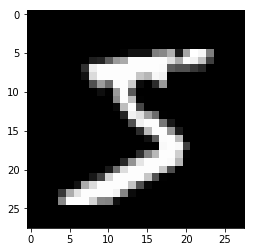

In [12]:
with tf.device('CPU:0'):
  cpu_model = build_model(allow_cudnn_kernel=True)
  cpu_model.set_weights(model.get_weights())
  result = tf.argmax(cpu_model.predict_on_batch(tf.expand_dims(sample, 0)), axis=1)
  print('Predicted result is: %s, target result is: %s' % (result.numpy(), sample_label))
  plt.imshow(sample, cmap=plt.get_cmap('gray'))